# Setup

In [24]:
import pandas as pd
import numpy as np
import pathlib
import xgboost as xgb


In [25]:
path = pathlib.Path.cwd().parent.parent.parent
df_path = path / 'data/synthetic/sensor_readings.parquet'
df = pd.read_parquet(df_path)

# Orden cronológico por máquina — obligatorio para que las ventanas rolling
# respeten el tiempo y no mezclen filas de distintas máquinas
df = df.sort_values(['machine_id', 'timestamp']).reset_index(drop=True)
df

,timestamp,machine_id,machine_type,vibration_rms,vibration_peak,temperature_bearing,temperature_motor,pressure_discharge,current_phase_a,current_phase_b,current_phase_c,speed_rpm,failure_mode,is_failure,degradation_fraction,rul_hours
0,2024-01-01 00:00:00,COMP-001,compressor,2.110398,3.018921,66.287337,76.420856,8.281605,35.629529,34.542999,35.145525,2937.078302,normal,False,0.0,NaN
1,2024-01-01 01:00:00,COMP-001,compressor,2.147380,3.475540,63.965131,75.375228,8.101300,36.005997,36.293649,34.943977,2953.231344,normal,False,0.0,NaN
2,2024-01-01 02:00:00,COMP-001,compressor,2.461734,3.609309,62.442358,70.329403,8.162788,36.209626,31.959964,32.568053,2937.620824,normal,False,0.0,NaN
3,2024-01-01 03:00:00,COMP-001,compressor,2.019104,2.770044,64.934317,71.914272,8.050934,35.301097,35.888209,34.168437,2929.115664,normal,False,0.0,NaN
4,2024-01-01 04:00:00,COMP-001,compressor,2.261088,3.776419,66.922401,71.814652,8.532285,34.711594,37.802509,32.634934,2944.839255,normal,False,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43795,2024-12-30 19:00:00,PUMP-002,centrifugal_pump,1.326417,1.961158,59.301140,54.249064,6.956524,21.868026,22.364086,22.705098,1447.073866,normal,False,0.0,NaN
43796,2024-12-30 20:00:00,PUMP-002,centrifugal_pump,1.499448,2.121794,59.178697,46.824519,7.197417,21.575748,20.906997,20.952524,1448.432761,normal,False,0.0,NaN
43797,2024-12-30 21:00:00,PUMP-002,centrifugal_pump,1.482776,2.108828,62.537813,51.414516,7.284134,21.634220,22.963890,22.711483,1447.588114,normal,False,0.0,NaN
43798,2024-12-30 22:00:00,PUMP-002,centrifugal_pump,1.512783,2.376964,58.905988,50.172561,7.291239,22.569185,22.721764,21.976749,1449.710441,normal,False,0.0,NaN


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43800 entries, 0 to 43799
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             43800 non-null  datetime64[us]
 1   machine_id            43800 non-null  object        
 2   machine_type          43800 non-null  object        
 3   vibration_rms         43800 non-null  float64       
 4   vibration_peak        43800 non-null  float64       
 5   temperature_bearing   43800 non-null  float64       
 6   temperature_motor     43800 non-null  float64       
 7   pressure_discharge    26280 non-null  float64       
 8   current_phase_a       43800 non-null  float64       
 9   current_phase_b       43800 non-null  float64       
 10  current_phase_c       43800 non-null  float64       
 11  speed_rpm             43800 non-null  float64       
 12  failure_mode          43800 non-null  object        
 13  is_failure      

In [27]:
df.machine_type.unique()

array(['compressor', 'induction_motor', 'centrifugal_pump'], dtype=object)

In [28]:
df.failure_mode.unique()

array(['normal', 'overheating', 'failure', 'bearing_wear',
       'electrical_failure', 'misalignment', 'cavitation'], dtype=object)

# Feature Engineering

In [29]:
# Sensores sobre los que se calculan todas las estadísticas rolling.
# pressure_discharge tiene NaN para induction_motor (ese tipo no tiene presión);
# las funciones lo propagan sin tratamiento especial — XGBoost/LightGBM lo manejan nativamente.
SENSORS = [
    'vibration_rms',
    'vibration_peak',
    'temperature_bearing',
    'temperature_motor',
    'pressure_discharge',
    'speed_rpm',
]

# Con datos horarios: 8 filas = 8h, 24 filas = 24h.
# La "ventana de 1h" se cubre con los delta features (diff de 1 paso).
WINDOWS = {'8h': 8, '24h': 24}

In [30]:
def add_rolling_stats(df):
    """
    Media, desviación estándar, máximo y kurtosis de cada sensor en ventanas de 8h y 24h.

    - mean:  nivel promedio en la ventana → baseline de operación
    - std:   variabilidad → sube antes del fallo por oscilaciones crecientes
    - max:   captura picos que la media suaviza
    - kurt:  colas pesadas (impactos repetidos) → señal temprana de desgaste en rodamientos

    groupby machine_id garantiza que la ventana de la máquina A
    no incluya datos de la máquina B.
    """
    out = df.copy()
    for sensor in SENSORS:
        grp = out.groupby('machine_id')[sensor]
        for label, w in WINDOWS.items():
            out[f'{sensor}_mean_{label}'] = grp.transform(lambda x: x.rolling(w, min_periods=2).mean())
            out[f'{sensor}_std_{label}']  = grp.transform(lambda x: x.rolling(w, min_periods=2).std())
            out[f'{sensor}_max_{label}']  = grp.transform(lambda x: x.rolling(w, min_periods=2).max())
            # kurtosis necesita mínimo 4 puntos para ser estadísticamente válida
            out[f'{sensor}_kurt_{label}'] = grp.transform(lambda x: x.rolling(w, min_periods=4).kurt())
    return out

In [31]:
def _linear_slope(arr):
    """Pendiente de regresión lineal (polyfit grado 1). Devuelve NaN si < 2 puntos válidos."""
    mask = ~np.isnan(arr)
    if mask.sum() < 2:
        return np.nan
    x = np.arange(len(arr))
    return np.polyfit(x[mask], arr[mask], 1)[0]


def add_trend_features(df):
    """
    Pendiente de regresión lineal de cada sensor en cada ventana temporal.

    Una pendiente positiva sostenida en temperatura o vibración = degradación progresiva.
    Es más informativo que la media porque captura la *dirección* del cambio,
    no solo el nivel absoluto.
    Usa np.polyfit en vez de scipy.linregress — más rápido en rolling.apply.
    """
    out = df.copy()
    for sensor in SENSORS:
        grp = out.groupby('machine_id')[sensor]
        for label, w in WINDOWS.items():
            out[f'{sensor}_slope_{label}'] = grp.transform(
                lambda x: x.rolling(w, min_periods=2).apply(_linear_slope, raw=True)
            )
    return out

In [32]:
def add_delta_features(df):
    """
    Diferencias entre la lectura actual y lecturas anteriores a distintas distancias.

    - delta_1h:  cambio respecto a la hora anterior (variación puntual)
    - delta_8h:  cambio respecto a hace 8 horas (tendencia de turno)
    - delta_24h: cambio respecto a hace 24 horas (tendencia diaria)
    - accel:     segunda diferencia discreta — ¿se está acelerando el deterioro?
    """
    out = df.copy()
    for sensor in SENSORS:
        grp = out.groupby('machine_id')[sensor]
        out[f'{sensor}_delta_1h']  = grp.transform(lambda x: x.diff(1))
        out[f'{sensor}_delta_8h']  = grp.transform(lambda x: x.diff(8))
        out[f'{sensor}_delta_24h'] = grp.transform(lambda x: x.diff(24))
        # Segunda derivada discreta: ¿aumenta el ritmo de cambio?
        out[f'{sensor}_accel']     = grp.transform(lambda x: x.diff(1).diff(1))
    return out

In [33]:
def add_cross_sensor_features(df):
    """
    Features derivadas de la interacción entre sensores.
    Ningún sensor individual puede revelar estos patrones por sí solo.

    - current_imbalance:    std entre las 3 fases → falla eléctrica incipiente
    - temp_per_rpm:         temperatura normalizada por velocidad → separa calor
                            por carga operativa vs calor por degradación mecánica
    - vibro_thermal_stress: vibración × temperatura → indicador de estrés combinado
    - temp_ratio:           bearing / motor → divergencia indica falla localizada en rodamiento
    - current_mean:         corriente promedio de las 3 fases → carga eléctrica total
    """
    out = df.copy()
    out['current_imbalance']    = out[['current_phase_a', 'current_phase_b', 'current_phase_c']].std(axis=1)
    out['temp_per_rpm']         = out['temperature_bearing'] / out['speed_rpm'].replace(0, np.nan)
    out['vibro_thermal_stress'] = out['vibration_rms'] * out['temperature_bearing']
    out['temp_ratio']           = out['temperature_bearing'] / out['temperature_motor'].replace(0, np.nan)
    out['current_mean']         = out[['current_phase_a', 'current_phase_b', 'current_phase_c']].mean(axis=1)
    return out

In [34]:
def add_baseline_normalization(df):
    """
    Normaliza cada sensor respecto al comportamiento sano inicial de cada máquina.
    Usa las primeras 168 horas (7 días) como referencia de operación normal.

    El desvío respecto al baseline es la señal real de degradación:
    un sensor que sube 5°C sobre su propio baseline es mucho más informativo
    que un valor absoluto de 70°C (que varía por tipo de máquina y condiciones).

   
    """
    out = df.copy()
    for sensor in SENSORS:
        # transform propaga el escalar (media de las primeras 168 filas del grupo)
        # a todas las filas de ese grupo — sin necesidad de merge
        baseline = out.groupby('machine_id')[sensor].transform(lambda x: x.iloc[:168].mean())
        out[f'{sensor}_vs_baseline'] = out[sensor] - baseline
    return out


def build_features(df):
    """
    Pipeline completo de feature engineering.
    Aplica las 5 transformaciones en orden y devuelve el DataFrame enriquecido.
    Opera sobre una copia — el df original no se modifica.
    """
    print("1/5  Rolling stats (mean / std / max / kurt × 8h y 24h)...")
    df = add_rolling_stats(df)
    print("2/5  Tendencias (pendiente lineal × 8h y 24h)...")
    df = add_trend_features(df)
    print("3/5  Deltas (1h / 8h / 24h / aceleración)...")
    df = add_delta_features(df)
    print("4/5  Features cross-sensor...")
    df = add_cross_sensor_features(df)
    print("5/5  Normalización por baseline de máquina...")
    df = add_baseline_normalization(df)
    print(f"\nDone. Shape final: {df.shape}")
    return df

# Encoding

In [35]:
df_feat = build_features(df.copy())

# --- Validación del DataFrame resultante ---
new_cols = [c for c in df_feat.columns if c not in df.columns]

print(f"\n{'='*52}")
print(f"Filas:               {df_feat.shape[0]:,}")
print(f"Columnas originales: {len(df.columns)}")
print(f"Columnas nuevas:     {len(new_cols)}")
print(f"Total columnas:      {df_feat.shape[1]}")

# Las primeras N filas de cada máquina tendrán NaN en las ventanas rolling
# porque no tienen historia suficiente — esto es esperado y no un error
null_pct = df_feat[new_cols].isnull().mean().sort_values(ascending=False)
print(f"\nFeatures con nulos (top 10 — esperado en primeras filas de cada máquina):")
print(null_pct[null_pct > 0].head(10).apply(lambda x: f"{x:.1%}").to_string())

# Verificar que no hay contaminación entre máquinas
n_machines = df_feat['machine_id'].nunique()
print(f"\nMáquinas: {n_machines}  |  Filas/máquina: {df_feat.shape[0] // n_machines}")

# Resumen de las features cross-sensor
cross_cols = ['current_imbalance', 'temp_per_rpm', 'vibro_thermal_stress', 'temp_ratio', 'current_mean']
df_feat[cross_cols].describe().round(3)

1/5  Rolling stats (mean / std / max / kurt × 8h y 24h)...
2/5  Tendencias (pendiente lineal × 8h y 24h)...


/Users/juanmanuel/dev/autonomous-maintenance-intelligence-agent/.venv/lib/python3.13/site-packages/pandas/core/window/rolling.py:611: RuntimeWarning: All-NaN slice encountered
  return func(x, start, end, min_periods, *numba_args)
/Users/juanmanuel/dev/autonomous-maintenance-intelligence-agent/.venv/lib/python3.13/site-packages/pandas/core/window/rolling.py:611: RuntimeWarning: All-NaN slice encountered
  return func(x, start, end, min_periods, *numba_args)


3/5  Deltas (1h / 8h / 24h / aceleración)...
4/5  Features cross-sensor...
5/5  Normalización por baseline de máquina...

Done. Shape final: (43800, 111)

Filas:               43,800
Columnas originales: 16
Columnas nuevas:     95
Total columnas:      111

Features con nulos (top 10 — esperado en primeras filas de cada máquina):
pressure_discharge_delta_24h    40.2%
pressure_discharge_delta_8h     40.1%
pressure_discharge_kurt_24h     40.0%
pressure_discharge_kurt_8h      40.0%
pressure_discharge_accel        40.0%
pressure_discharge_max_8h       40.0%
pressure_discharge_max_24h      40.0%
pressure_discharge_delta_1h     40.0%
pressure_discharge_std_24h      40.0%
pressure_discharge_slope_24h    40.0%

Máquinas: 5  |  Filas/máquina: 8760


,current_imbalance,temp_per_rpm,vibro_thermal_stress,temp_ratio,current_mean
count,43800.000,43800.000,43800.000,43800.000,43800.000
mean,0.870,0.035,88.525,0.981,23.978
std,0.727,0.008,61.353,0.154,7.378
min,0.003,0.019,32.889,0.664,11.486
25%,0.462,0.034,59.186,0.850,18.237
50%,0.745,0.037,69.468,0.926,22.095
75%,1.122,0.039,95.747,1.126,28.653
max,24.274,0.084,904.596,1.528,118.362


In [36]:
# Columnas que causan data leakage — son consecuencia del fallo,
# no variables observables antes de que ocurra en producción
LEAKAGE_COLS = ['failure_mode', 'is_failure', 'degradation_fraction', 'rul_hours']
META_COLS    = ['timestamp', 'machine_id', 'machine_type', 'label']

# machine_type: codificación ordinal — XGBoost/LightGBM no requieren one-hot
machine_type_map = {'compressor': 0, 'induction_motor': 1, 'centrifugal_pump': 2}
df_feat['machine_type_enc'] = df_feat['machine_type'].map(machine_type_map)

FEATURE_COLS = [c for c in df_feat.columns if c not in LEAKAGE_COLS + META_COLS]

print(f"Features de entrenamiento: {len(FEATURE_COLS)}")
print(f"Leakage descartado:        {LEAKAGE_COLS}")
print(f"\nPrimeras 10 features:")
print(FEATURE_COLS[:10])

Features de entrenamiento: 105
Leakage descartado:        ['failure_mode', 'is_failure', 'degradation_fraction', 'rul_hours']

Primeras 10 features:
['vibration_rms', 'vibration_peak', 'temperature_bearing', 'temperature_motor', 'pressure_discharge', 'current_phase_a', 'current_phase_b', 'current_phase_c', 'speed_rpm', 'vibration_rms_mean_8h']


# Definicion de Target

In [37]:
# --- Creación del target binario ---
# Pregunta: ¿fallará esta máquina en las próximas 24 horas?
#
# Lógica paso a paso:
#   1. astype(int):        convierte bool → 0 / 1
#   2. shift(-24):         desplaza la serie 24 pasos hacia adelante (miramos el futuro)
#   3. rolling(24).max():  si ANY de las próximas 24 lecturas es fallo → marca 1
#   4. fillna(0):          las últimas 24 filas de cada máquina no tienen futuro → 0
#
# Se opera dentro de cada machine_id para no cruzar señales entre máquinas.

df_feat['label'] = (
    df_feat.groupby('machine_id')['is_failure']
           .transform(lambda x: x.astype(int).shift(-24).rolling(24, min_periods=1).max())
           .fillna(0)
           .astype(int)
)

counts = df_feat['label'].value_counts()
ratio = counts[0] / counts.get(1, 1)
print(f"Clase 0 — operación normal:   {counts[0]:,}")
print(f"Clase 1 — fallo en < 24h:     {counts.get(1, 0):,}")
print(f"\nRatio desbalance: {ratio:.1f}:1")
print(f"→ Parámetros recomendados:")
print(f"    XGBoost:   scale_pos_weight={ratio:.0f}")
print(f"    LightGBM:  is_unbalance=True  (o scale_pos_weight={ratio:.0f})")
print(f"→ Métrica principal: PR-AUC o F1, NO accuracy")

Clase 0 — operación normal:   42,984
Clase 1 — fallo en < 24h:     816

Ratio desbalance: 52.7:1
→ Parámetros recomendados:
    XGBoost:   scale_pos_weight=53
    LightGBM:  is_unbalance=True  (o scale_pos_weight=53)
→ Métrica principal: PR-AUC o F1, NO accuracy


# Train/Test

In [38]:
# Split temporal — NUNCA aleatorio con series de tiempo.
# Un split aleatorio "filtraría el futuro al pasado" a través de las ventanas rolling:
# la rolling_mean_24h de una fila de test ya habría visto datos de train → leakage sutil.
# Corte 2024-11-01 → ~83% train (ene-oct) / ~17% test (nov-dic)

SPLIT_DATE = pd.Timestamp('2024-11-01')

train_mask = df_feat['timestamp'] < SPLIT_DATE
test_mask  = df_feat['timestamp'] >= SPLIT_DATE

X_train = df_feat.loc[train_mask, FEATURE_COLS]
X_test  = df_feat.loc[test_mask,  FEATURE_COLS]
y_train = df_feat.loc[train_mask, 'label']
y_test  = df_feat.loc[test_mask,  'label']

print(f"Train: {len(X_train):,} filas  |  positivos: {y_train.sum():,} ({y_train.mean():.2%})")
print(f"Test:  {len(X_test):,} filas   |  positivos: {y_test.sum():,} ({y_test.mean():.2%})")
print(f"\nNaN en train: {X_train.isnull().any().sum()} features  "
      f"(XGBoost los maneja nativamente — no se imputa)")

Train: 36,600 filas  |  positivos: 711 (1.94%)
Test:  7,200 filas   |  positivos: 105 (1.46%)

NaN en train: 86 features  (XGBoost los maneja nativamente — no se imputa)


In [39]:
import xgboost as xgb

# scale_pos_weight=50 causó parada en iteración 1 — gradientes demasiado grandes
# en los primeros árboles → el modelo pica en iter 1 y luego sobreajusta ruido.
# Solución: escala suavizada (sqrt del ratio real) + regularización explícita.
# XGBoost docs recomiendan max_delta_step=1 específicamente para clases muy desbalanceadas.
SCALE_POS_WEIGHT = int(np.sqrt(y_train.value_counts()[0] / y_train.value_counts()[1]) * 3)
print(f"scale_pos_weight corregido: {SCALE_POS_WEIGHT}  (antes: 50)")

model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=5,             # menos profundo → menos sobreajuste
    learning_rate=0.02,      # pasos pequeños → más iteraciones antes del óptimo
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=5,      # evita splits con muy pocos positivos
    gamma=0.5,               # umbral mínimo de ganancia para hacer un split
    reg_lambda=3.0,          # L2 — penaliza pesos grandes
    reg_alpha=1.0,           # L1 — sparsifica el modelo
    max_delta_step=1,        # limita el paso de actualización (recomendado para imbalance)
    scale_pos_weight=SCALE_POS_WEIGHT,
    eval_metric='logloss',   # más estable que aucpr para guiar early stopping
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100,
)

print(f"\nMejor iteración:      {model.best_iteration}")
print(f"Mejor logloss eval:   {model.best_score:.4f}")

scale_pos_weight corregido: 21  (antes: 50)
[0]	validation_0-logloss:0.36973
[100]	validation_0-logloss:0.08480
[200]	validation_0-logloss:0.03912
[300]	validation_0-logloss:0.02941
[400]	validation_0-logloss:0.02515
[500]	validation_0-logloss:0.02334
[600]	validation_0-logloss:0.02152
[700]	validation_0-logloss:0.02059
[800]	validation_0-logloss:0.01998
[900]	validation_0-logloss:0.01965
[936]	validation_0-logloss:0.01962

Mejor iteración:      886
Mejor logloss eval:   0.0196


# Evaluacion

PR-AUC:  0.7544  ← métrica principal (desbalance severo)
ROC-AUC: 0.9962

── Umbral 0.5 (defecto) ──
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00      7095
   fallo_24h       0.70      0.77      0.73       105

    accuracy                           0.99      7200
   macro avg       0.85      0.88      0.86      7200
weighted avg       0.99      0.99      0.99      7200

── Umbral óptimo por F1: 0.460 ──
              precision    recall  f1-score   support

      normal       1.00      0.99      1.00      7095
   fallo_24h       0.70      0.81      0.75       105

    accuracy                           0.99      7200
   macro avg       0.85      0.90      0.87      7200
weighted avg       0.99      0.99      0.99      7200



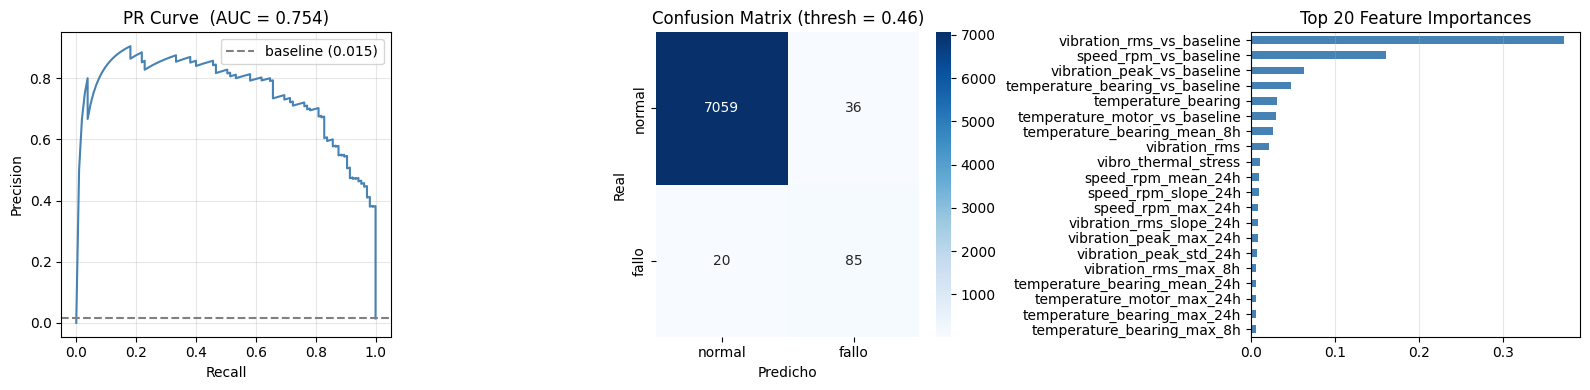

In [40]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score,
    roc_auc_score,
)
import matplotlib.pyplot as plt
import seaborn as sns

y_prob = model.predict_proba(X_test)[:, 1]

pr_auc  = average_precision_score(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"PR-AUC:  {pr_auc:.4f}  ← métrica principal (desbalance severo)")
print(f"ROC-AUC: {roc_auc:.4f}\n")

# Con umbral por defecto (0.5)
print("── Umbral 0.5 (defecto) ──")
print(classification_report(y_test, (y_prob >= 0.5).astype(int),
                             target_names=['normal', 'fallo_24h']))

# Buscar umbral que maximiza F1 en test
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
f1_per_thresh = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-8)
best_thresh   = thresholds[np.argmax(f1_per_thresh)]
y_pred_opt    = (y_prob >= best_thresh).astype(int)

print(f"── Umbral óptimo por F1: {best_thresh:.3f} ──")
print(classification_report(y_test, y_pred_opt, target_names=['normal', 'fallo_24h']))

# --- Visualizaciones ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Curva Precision-Recall
axes[0].plot(recalls[:-1], precisions[:-1], color='steelblue')
axes[0].axhline(y_test.mean(), ls='--', color='gray', label=f'baseline ({y_test.mean():.3f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title(f'PR Curve  (AUC = {pr_auc:.3f})')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Confusion matrix con umbral óptimo
cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[1], cmap='Blues',
            xticklabels=['normal', 'fallo'], yticklabels=['normal', 'fallo'])
axes[1].set_title(f'Confusion Matrix (thresh = {best_thresh:.2f})')
axes[1].set_ylabel('Real'); axes[1].set_xlabel('Predicho')

# Feature importance top 20
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).nlargest(20)
importances.sort_values().plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Top 20 Feature Importances')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(path / 'data/synthetic/model_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

## Feature importances — hallazgo clave



#### 'Los _vs_baseline' dominan el modelo:


vibration_rms_vs_baseline       37.25%  ← señal principal
speed_rpm_vs_baseline           16.11%
vibration_peak_vs_baseline       6.29%
temperature_bearing_vs_baseline  4.83%

**La normalización por baseline fue la decisión de feature engineering más impactante. El modelo aprendió que el desvío respecto al comportamiento propio de cada máquina es mucho más discriminativo que los valores absolutos de los sensores.**

vibro_thermal_stress también aparece (0.011), validando el cross-sensor.